In [1]:
import os
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.utils import make_grid

from tqdm import tqdm

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [3]:
IMAGE_SIZE = 64

BATCH_SIZE = 4

EPOCHS = 10

LR = 0.0002

LAMBDA_CYCLE = 10

In [4]:
class FaceMonetDataset(Dataset):

    def __init__(
        self,
        face_dir,
        monet_dir,
        transform
    ):

        self.transform = transform

        self.faces = []

        for celeb in os.listdir(face_dir):

            celeb_path = os.path.join(
                face_dir,
                celeb
            )

            if os.path.isdir(celeb_path):

                for img in os.listdir(
                    celeb_path
                ):

                    if img.lower().endswith(
                        (".jpg",".jpeg",".png")
                    ):

                        self.faces.append(
                            os.path.join(
                                celeb_path,
                                img
                            )
                        )

        self.monet = []

        for img in os.listdir(monet_dir):

            if img.lower().endswith(
                (".jpg",".jpeg",".png")
            ):

                self.monet.append(
                    os.path.join(
                        monet_dir,
                        img
                    )
                )

    def __len__(self):

        return max(
            len(self.faces),
            len(self.monet)
        )

    def __getitem__(self, idx):

        face = Image.open(
            self.faces[
                idx % len(self.faces)
            ]
        ).convert("RGB")

        monet = Image.open(
            random.choice(
                self.monet
            )
        ).convert("RGB")

        face = self.transform(face)
        monet = self.transform(monet)

        return face, monet

In [5]:
transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

In [6]:
dataset = FaceMonetDataset(

    face_dir=
    "/home/saidul/Desktop/4-2/Deep Learning/data/5_celebrity_faces/train",

    monet_dir=
    "/home/saidul/Desktop/4-2/Deep Learning/data/monet_painting/monet",

    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(len(dataset))

1193


In [7]:
class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                3,
                1,
                1
            ),

            nn.InstanceNorm2d(
                channels
            ),

            nn.ReLU(True),

            nn.Conv2d(
                channels,
                channels,
                3,
                1,
                1
            ),

            nn.InstanceNorm2d(
                channels
            )
        )

    def forward(self, x):

        return x + self.block(x)

In [8]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                7,
                1,
                3
            ),

            nn.ReLU(True),

            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),

            nn.Conv2d(
                64,
                64,
                3,
                1,
                1
            ),

            nn.ReLU(True),

            nn.Conv2d(
                64,
                3,
                7,
                1,
                3
            ),

            nn.Tanh()
        )

    def forward(self, x):

        return self.model(x)

In [9]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                4,
                2,
                1
            ),

            nn.LeakyReLU(
                0.2
            ),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1
            ),

            nn.InstanceNorm2d(
                128
            ),

            nn.LeakyReLU(
                0.2
            ),

            nn.Conv2d(
                128,
                1,
                4,
                1,
                1
            )
        )

    def forward(self,x):

        return self.model(x)

In [10]:
G_F2M = Generator().to(device)

G_M2F = Generator().to(device)

D_F = Discriminator().to(device)

D_M = Discriminator().to(device)

In [11]:
adv_loss = nn.MSELoss()

cycle_loss = nn.L1Loss()

In [12]:
optimizer_G = torch.optim.Adam(

    itertools.chain(
        G_F2M.parameters(),
        G_M2F.parameters()
    ),

    lr=LR,
    betas=(0.5,0.999)
)

optimizer_DF = torch.optim.Adam(
    D_F.parameters(),
    lr=LR,
    betas=(0.5,0.999)
)

optimizer_DM = torch.optim.Adam(
    D_M.parameters(),
    lr=LR,
    betas=(0.5,0.999)
)

In [13]:
for epoch in range(EPOCHS):

    for face, monet in tqdm(loader):

        face = face.to(device)
        monet = monet.to(device)

        ################################
        # Train Generators
        ################################

        optimizer_G.zero_grad()

        fake_monet = G_F2M(face)

        fake_face = G_M2F(monet)

        adv_fm = adv_loss(
            D_M(fake_monet),
            torch.ones_like(
                D_M(fake_monet)
            )
        )

        adv_mf = adv_loss(
            D_F(fake_face),
            torch.ones_like(
                D_F(fake_face)
            )
        )

        rec_face = G_M2F(
            fake_monet
        )

        rec_monet = G_F2M(
            fake_face
        )

        cyc_face = cycle_loss(
            rec_face,
            face
        )

        cyc_monet = cycle_loss(
            rec_monet,
            monet
        )

        loss_G = (
            adv_fm +
            adv_mf +
            LAMBDA_CYCLE *
            (
                cyc_face +
                cyc_monet
            )
        )

        loss_G.backward()

        optimizer_G.step()

        ################################
        # Train D_F
        ################################

        optimizer_DF.zero_grad()

        real_loss = adv_loss(
            D_F(face),
            torch.ones_like(
                D_F(face)
            )
        )

        fake_loss = adv_loss(
            D_F(
                fake_face.detach()
            ),
            torch.zeros_like(
                D_F(fake_face)
            )
        )

        loss_DF = (
            real_loss +
            fake_loss
        ) * 0.5

        loss_DF.backward()

        optimizer_DF.step()

        ################################
        # Train D_M
        ################################

        optimizer_DM.zero_grad()

        real_loss = adv_loss(
            D_M(monet),
            torch.ones_like(
                D_M(monet)
            )
        )

        fake_loss = adv_loss(
            D_M(
                fake_monet.detach()
            ),
            torch.zeros_like(
                D_M(fake_monet)
            )
        )

        loss_DM = (
            real_loss +
            fake_loss
        ) * 0.5

        loss_DM.backward()

        optimizer_DM.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"G={loss_G.item():.4f}"
    )

100%|██████████| 299/299 [06:16<00:00,  1.26s/it]


Epoch 1/10 G=3.2840


100%|██████████| 299/299 [06:44<00:00,  1.35s/it]


Epoch 2/10 G=2.8263


100%|██████████| 299/299 [06:30<00:00,  1.31s/it]


...

Epoch 8/10 G=2.3950


100%|██████████| 299/299 [06:19<00:00,  1.27s/it]


Epoch 9/10 G=2.2062


100%|██████████| 299/299 [06:33<00:00,  1.32s/it]

Epoch 10/10 G=3.1959


In [14]:
face, _ = dataset[0]

face = face.unsqueeze(0).to(device)

G_F2M.eval()

with torch.no_grad():

    translated = G_F2M(face)

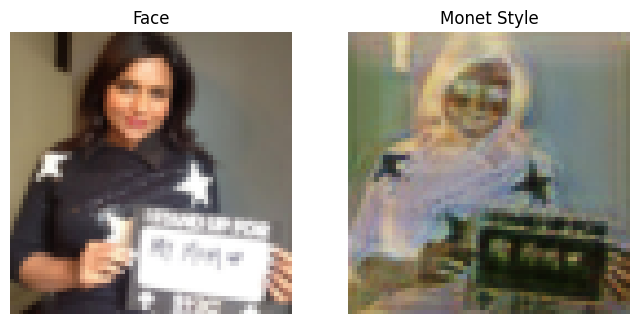

In [15]:
def denorm(x):

    return x*0.5 + 0.5

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

plt.imshow(
    np.transpose(
        denorm(face.cpu()[0]).numpy(),
        (1,2,0)
    )
)

plt.title("Face")
plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    np.transpose(
        denorm(translated.cpu()[0]).numpy(),
        (1,2,0)
    )
)

plt.title("Monet Style")
plt.axis("off")

plt.show()